### K-Mean

In [7]:
import os
import pandas as pd
import numpy as np

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

file_path = "/Users/calebarrivillaga/Desktop/UMIS_Homework/696_Milestone II/maritime-market-ml/models/unsupervised/merged_3W_testing_data.csv"

df = pd.read_csv(file_path)
df = df.dropna(subset=["Draft"])

ais_features = [
    "Tanker_Vessels",
    "Cargo_Vessels",
    "Draft",
    "Avg_SOG",
    "Avg_Length",
    "Unique_Vessels"
]

X = df[ais_features]

X.head()

,Tanker_Vessels,Cargo_Vessels,Draft,Avg_SOG,Avg_Length,Unique_Vessels
0,16,94,10.39,9.70,202.34,110
1,0,3,4.45,2.53,55.33,3
2,11,21,10.29,6.64,186.35,32
3,1,12,10.85,12.93,244.69,13
4,12,100,11.40,13.05,251.74,112


In [8]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

In [9]:
X_scaled.mean(axis=0)

array([-2.50359018e-17, -5.24561751e-17, -1.14449837e-15,  9.17983065e-17,
        7.86246534e-16, -5.24561751e-17])

In [10]:
X_scaled.std(axis=0)

array([1., 1., 1., 1., 1., 1.])

In [11]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

k_values = range(2, 11)

inertia_scores = []
silhouette_scores = []

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )
    
    cluster_labels = kmeans.fit_predict(X_scaled)
    
    inertia_scores.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(X_scaled, cluster_labels))

results = pd.DataFrame({
    "K": k_values,
    "Inertia": inertia_scores,
    "Silhouette Score": silhouette_scores
})

results

,K,Inertia,Silhouette Score
0,2,12912.321705,0.483457
1,3,8243.269445,0.536886
2,4,6328.462978,0.319974
3,5,4741.651161,0.375056
4,6,4093.091407,0.389672
5,7,3466.252214,0.403952
6,8,2982.114328,0.420371
7,9,2658.023400,0.416145
8,10,2340.571418,0.376442


In [12]:
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

df["Cluster"] = kmeans.fit_predict(X_scaled)

In [13]:
df["Cluster"].value_counts()

Cluster
0    2552
2     332
1      96
Name: count, dtype: int64

In [14]:
df.groupby("Cluster")[ais_features].mean()

,Tanker_Vessels,Cargo_Vessels,Draft,Avg_SOG,Avg_Length,Unique_Vessels
Cluster,,,,,,
0,29.032915,71.458856,10.727990,10.167265,215.054581,100.491771
1,0.000000,2.614583,3.651146,7.371146,44.400729,2.614583
2,177.036145,189.454819,10.091958,8.218705,195.321867,366.490964


In [15]:
df.groupby("Cluster")["Port"].value_counts().head(20)

Cluster  Port           
0        Baltimore          103
         Boston             103
         Camden (NJ)        103
         Charleston         103
         Corpus Christi     103
         Honolulu           103
         Jacksonville       103
         Mobile             103
         Oakland            103
         Philadelphia       103
         Port Everglades    103
         Portland           103
         Providence         103
         Puerto Rico        103
         San Diego          103
         San Francisco      103
         Tacoma             103
         Tampa              103
         Wilmington (DE)    103
         Savannah           102
Name: count, dtype: int64

In [16]:
pd.crosstab(df["Port"], df["Cluster"])

Cluster,0,1,2
Port,,,
Baltimore,103,0,0
Baton Rouge,0,96,0
Boston,103,0,0
Camden (NJ),103,0,0
Charleston,103,0,0
Corpus Christi,103,0,0
Honolulu,103,0,0
Houston,0,0,103
Jacksonville,103,0,0


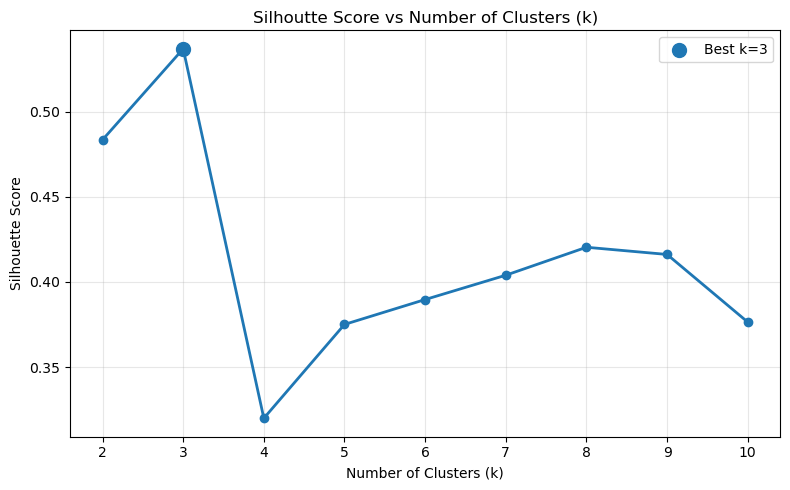

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(
    results["K"],
    results["Silhouette Score"],
    marker = "o",
    linewidth = 2
)

best_row = results.loc[
    results["Silhouette Score"].idxmax()
]

plt.scatter(
    best_row["K"],
    best_row["Silhouette Score"],
    s = 100,
    zorder = 5,
    label = f'Best k={int(best_row["K"])}'
)

plt.title("Silhoutte Score vs Number of Clusters (k)")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.xticks(results["K"])
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()



### Figure 1: Silhouette Scores vs Number of Clusters (k)

The highest Silhouette Score (0.5369) was achieved when k = 3, indicating the strongest balance between cluster cohesion and cluster separation. This result was used to select the optimal K-Means clustering solution.

In [22]:
import pandas as pd

train_df = pd.read_csv("/Users/calebarrivillaga/Desktop/UMIS_Homework/696_Milestone II/maritime-market-ml/models/unsupervised/merged_3W_training_data.csv")
test_df = pd.read_csv("/Users/calebarrivillaga/Desktop/UMIS_Homework/696_Milestone II/maritime-market-ml/models/unsupervised/merged_3W_testing_data.csv")


In [24]:
combined_df = pd.concat(
    [train_df, test_df],
    ignore_index=True
)

In [25]:
weekly_df = (
    combined_df.groupby("Week")
      .agg({
          "Tanker_Vessels": "sum",
          "Cargo_Vessels": "sum",
          "Draft": "mean",
          "Avg_SOG": "mean",
          "Avg_Length": "mean",
          "Unique_Vessels": "sum"
      })
      .reset_index()
)

In [26]:
weekly_df["Month"] = pd.to_datetime(
    weekly_df["Week"]
).dt.month

weekly_df["Quarter_Month"] = (
    ((weekly_df["Month"] - 1) % 3) + 1
)

In [27]:
weekly_df.groupby("Quarter_Month")[
    [
        "Tanker_Vessels",
        "Cargo_Vessels",
        "Unique_Vessels"
    ]
].mean()

,Tanker_Vessels,Cargo_Vessels,Unique_Vessels
Quarter_Month,,,
1,1216.363636,2341.250000,3557.613636
2,1088.220930,2117.186047,3205.406977
3,1111.197674,2114.837209,3226.034884


In [28]:
weekly_df["Quarter_Start"] = (
    weekly_df["Month"].isin([1,4,7,10])
)

In [29]:
# t-test
from scipy.stats import ttest_ind

# Make sure Quarter_Start exists
weekly_df["Quarter_Start"] = weekly_df["Quarter_Month"] == 1

features_to_test = [
    "Tanker_Vessels",
    "Cargo_Vessels",
    "Unique_Vessels"
]

for feature in features_to_test:
    quarter_start = weekly_df.loc[
        weekly_df["Quarter_Start"],
        feature
    ]

    non_quarter_start = weekly_df.loc[
        ~weekly_df["Quarter_Start"],
        feature
    ]

    result = ttest_ind(
        quarter_start,
        non_quarter_start,
        equal_var=False
    )

    print(f"\nFeature: {feature}")
    print(f"Quarter Start Mean: {quarter_start.mean():.2f}")
    print(f"Non-Quarter Start Mean: {non_quarter_start.mean():.2f}")
    print(f"T-statistic: {result.statistic:.4f}")
    print(f"P-value: {result.pvalue:.4f}")


Feature: Tanker_Vessels
Quarter Start Mean: 1216.36
Non-Quarter Start Mean: 1099.71
T-statistic: 3.6923
P-value: 0.0003

Feature: Cargo_Vessels
Quarter Start Mean: 2341.25
Non-Quarter Start Mean: 2116.01
T-statistic: 4.2314
P-value: 0.0000

Feature: Unique_Vessels
Quarter Start Mean: 3557.61
Non-Quarter Start Mean: 3215.72
T-statistic: 4.1106
P-value: 0.0001


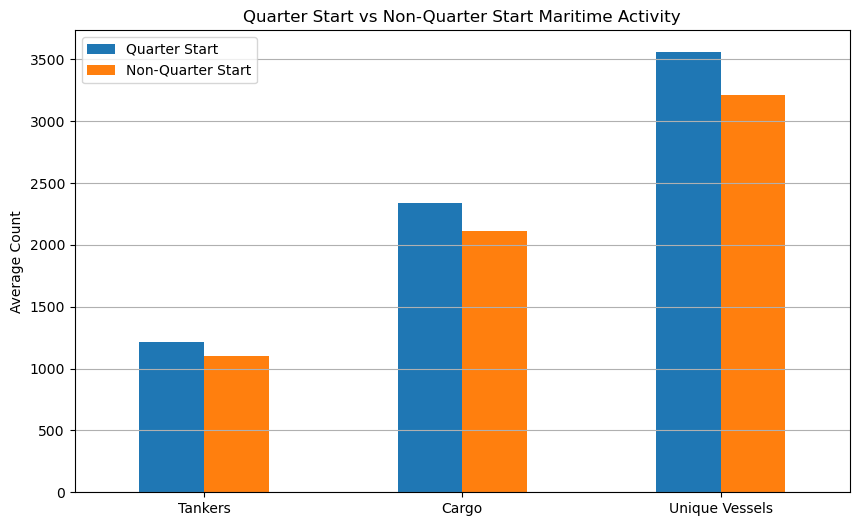

In [30]:
import pandas as pd
import matplotlib.pyplot as plt

summary = pd.DataFrame({
    "Quarter Start": [
        weekly_df.loc[
            weekly_df["Quarter_Start"],
            "Tanker_Vessels"
        ].mean(),

        weekly_df.loc[
            weekly_df["Quarter_Start"],
            "Cargo_Vessels"
        ].mean(),

        weekly_df.loc[
            weekly_df["Quarter_Start"],
            "Unique_Vessels"
        ].mean()
    ],

    "Non-Quarter Start": [
        weekly_df.loc[
            ~weekly_df["Quarter_Start"],
            "Tanker_Vessels"
        ].mean(),

        weekly_df.loc[
            ~weekly_df["Quarter_Start"],
            "Cargo_Vessels"
        ].mean(),

        weekly_df.loc[
            ~weekly_df["Quarter_Start"],
            "Unique_Vessels"
        ].mean()
    ]

}, index=[
    "Tankers",
    "Cargo",
    "Unique Vessels"
])

summary.plot(
    kind="bar",
    figsize=(10,6)
)

plt.title(
    "Quarter Start vs Non-Quarter Start Maritime Activity"
)

plt.ylabel("Average Count")

plt.xticks(rotation=0)

plt.grid(axis="y")

plt.show()

###	Figure 2. Quarter Start vs Non_Quarter Start Maritime Activity. 

Average tanker vessel counts, cargo vessel counts, and unique vessel counts were consistently higher during quarter-start periods (January, April, July, and October) compared to the non-quarter start periods. This pattern suggests the presence of recurring seasonal and quarterly shipping regimes within the maritime dataset.

In [31]:
weekly_df.groupby("Quarter_Start")[
    [
        "Tanker_Vessels",
        "Cargo_Vessels",
        "Unique_Vessels"
    ]
].agg(["mean","std"])

Tanker_Vessels             Cargo_Vessels              \
                        mean         std          mean         std   
Quarter_Start                                                        
False            1099.709302  172.175544   2116.011628  270.123342   
True             1216.363636  269.575621   2341.250000  460.443745   

              Unique_Vessels              
                        mean         std  
Quarter_Start                             
False            3215.720930  423.297820  
True             3557.613636  719.092778

In [40]:
from scipy.stats import ttest_ind

# tanker vessels
tanker_t, tanker_p = ttest_ind(
    weekly_df.loc[weekly_df["Quarter_Start"], "Tanker_Vessels"],
    weekly_df.loc[~weekly_df["Quarter_Start"], "Tanker_Vessels"],
    equal_var = False
)

# Cargo vessels
cargo_t, cargo_p = ttest_ind(
    weekly_df.loc[weekly_df["Quarter_Start"], "Cargo_Vessels"],
    weekly_df.loc[~weekly_df["Quarter_Start"], "Cargo_Vessels"],
    equal_var = False
)

# Unique vessels
unique_t, unique_p = ttest_ind(
    weekly_df.loc[weekly_df["Quarter_Start"], "Unique_Vessels"],
    weekly_df.loc[~weekly_df["Quarter_Start"], "Unique_Vessels"],
    equal_var = False
)

results = pd.DataFrame({
    "Feature": [
        "Tanker_Vessels",
        "Cargo_Vessels",
        "Unique_Vessels",
    ],

    " T Statistic":[
        tanker_t,
        cargo_t,
        unique_t
    ],
    "P Value":[
        tanker_p,
        cargo_p,
        unique_p
    ]
})

results

,Feature,T Statistic,P Value
0,Tanker_Vessels,3.692336,0.000331
1,Cargo_Vessels,4.231434,0.000046
2,Unique_Vessels,4.110599,0.000073


Finding
A recurring quarter-start maritime regime exists.
Evidence
Discovered through K-Means clustering.
Reproduced on the full 2019-2024 dataset.
Significant increases in:
Tanker activity (+10.6%)
Cargo activity (+10.6%)
Unique vessel participation (+10.6%)
Supported by t-tests:
Tankers: p = 0.0003
Cargo: p < 0.0001
Unique Vessels: p = 0.0001